<a href="https://colab.research.google.com/github/chinwejoseph/IBM-data-analyst-certification-labs/blob/main/Project_9b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

--2026-03-12 17:31:52--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 198.23.119.245
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|198.23.119.245|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  87.0MB/s    in 1.7s    

2026-03-12 17:31:54 (87.0 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



In [2]:
!pip install pandas
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

In [3]:
#Read the csv file
df =pd.read_csv("survey-data.csv")

#display the first few rows of the data
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [4]:
import sqlite3

# Create a connection to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Write the dataframe to the SQLite database
df.to_sql('main', conn, if_exists='replace', index=False)


# Close the connection
conn.close()

In [7]:
# Reconnect to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Run a simple query to check the data
QUERY = "SELECT * FROM main LIMIT 5"
df_check = pd.read_sql_query(QUERY, conn)

# Display the results
print(df_check)

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time       None  Apples   
4   Student, full-time       None  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                               None   
4                                 

In [8]:
QUERY = """
SELECT COUNT(*)
FROM main
"""
df = pd.read_sql_query(QUERY, conn)
df.head()

,COUNT(*)
0,65437


In [12]:
#view the names of all tables in the database
QUERY = """
SELECT name FROM sqlite_master WHERE type='table';
"""
df = pd.read_sql_query(QUERY, conn)

In [14]:
#group data by a specific column, like Age, to get the count of respondents in each age group
QUERY = """
SELECT Age, COUNT(*) AS Count
FROM main
GROUP BY Age
ORDER BY age
"""
pd.read_sql_query(QUERY, conn)

,Age,Count
0,18-24 years old,14098
1,25-34 years old,23911
2,35-44 years old,14942
3,45-54 years old,6249
4,55-64 years old,2575
5,65 years or older,772
6,Prefer not to say,322
7,Under 18 years old,2568


In [15]:
#get the schema of a specific table - main
QUERY = """
PRAGMA table_info(main);
"""
pd.read_sql_query(QUERY, conn)

,cid,name,type,notnull,dflt_value,pk
0,0,ResponseId,INTEGER,0,None,0
1,1,MainBranch,TEXT,0,None,0
2,2,Age,TEXT,0,None,0
3,3,Employment,TEXT,0,None,0
4,4,RemoteWork,TEXT,0,None,0
...,...,...,...,...,...,...
109,109,JobSatPoints_11,REAL,0,None,0
110,110,SurveyLength,TEXT,0,None,0
111,111,SurveyEase,TEXT,0,None,0
112,112,ConvertedCompYearly,REAL,0,None,0


,CompTotal,Count
0,NaN,31697
1,0.000000e+00,127
2,1.000000e+00,12
3,2.000000e+00,4
4,3.000000e+00,1
...,...,...
3333,8.000000e+27,1
3334,1.000000e+44,1
3335,1.000000e+53,1
3336,1.000000e+65,1


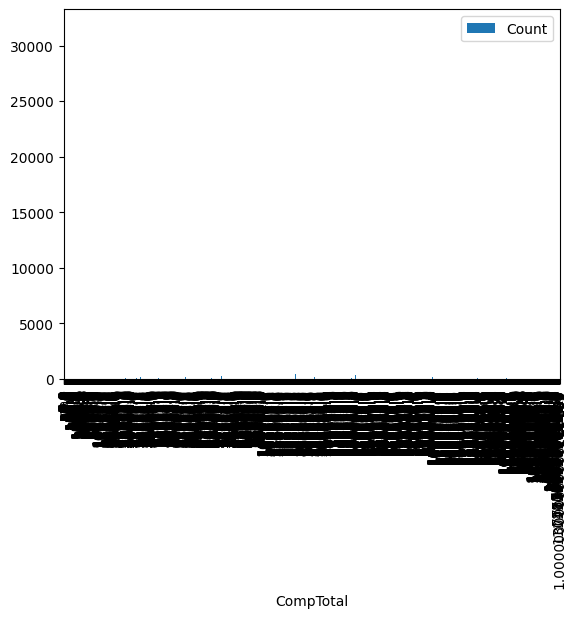

In [17]:
#Plot a histogram of CompTotal
QUERY = """
SELECT CompTotal, COUNT(*) AS Count
FROM main
GROUP BY CompTotal
ORDER BY CompTotal
"""
pd.read_sql_query(QUERY, conn).plot(kind='bar', x='CompTotal', y='Count')
pd.read_sql_query(QUERY, conn)


,Age,Count
0,18-24 years old,14098
1,25-34 years old,23911
2,35-44 years old,14942
3,45-54 years old,6249
4,55-64 years old,2575
5,65 years or older,772
6,Prefer not to say,322
7,Under 18 years old,2568


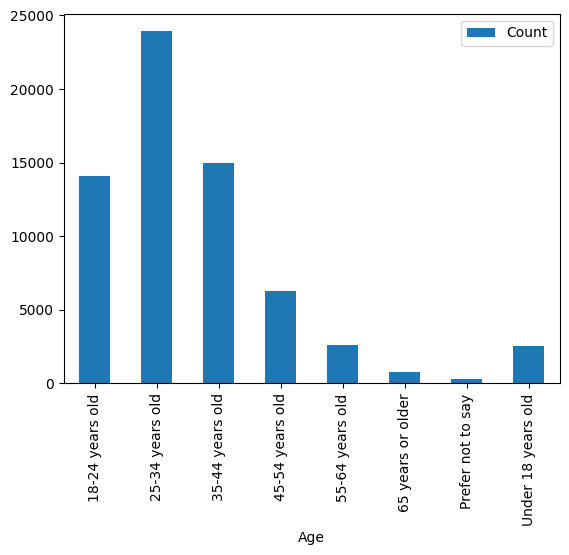

In [18]:
#Plot a box plot of Age
QUERY = """
SELECT Age, COUNT(*) AS Count
FROM main
GROUP BY Age
ORDER BY Age
"""
pd.read_sql_query(QUERY, conn).plot(kind='bar', x='Age', y='Count')
pd.read_sql_query(QUERY, conn)


,Age,WorkExp,Count
0,18-24 years old,NaN,9807
1,18-24 years old,0.0,148
2,18-24 years old,1.0,1042
3,18-24 years old,2.0,1107
4,18-24 years old,3.0,876
...,...,...,...
249,Under 18 years old,6.0,1
250,Under 18 years old,8.0,1
251,Under 18 years old,9.0,1
252,Under 18 years old,31.0,1


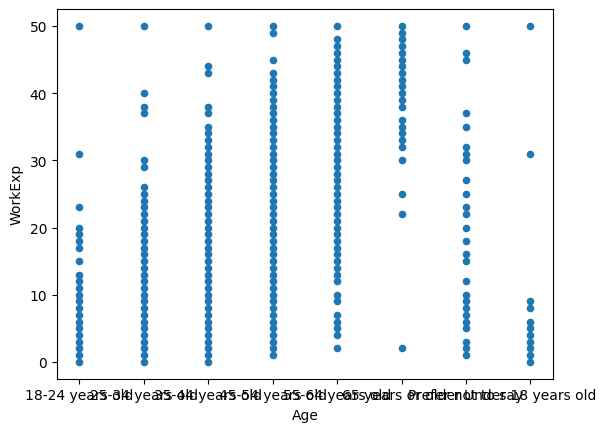

In [20]:
#Create a scatter plot of Age and WorkExp
QUERY = """
SELECT Age, WorkExp, COUNT(*) AS Count
FROM main
GROUP BY Age, WorkExp
ORDER BY Age, WorkExp
"""
pd.read_sql_query(QUERY, conn).plot(kind='scatter', x='Age', y='WorkExp')
pd.read_sql_query(QUERY, conn)

/tmp/ipykernel_306/3358693537.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  plot_data['Age_numeric'].fillna(0, inplace=True)


<Axes: xlabel='TimeSearching', ylabel='Frustration'>

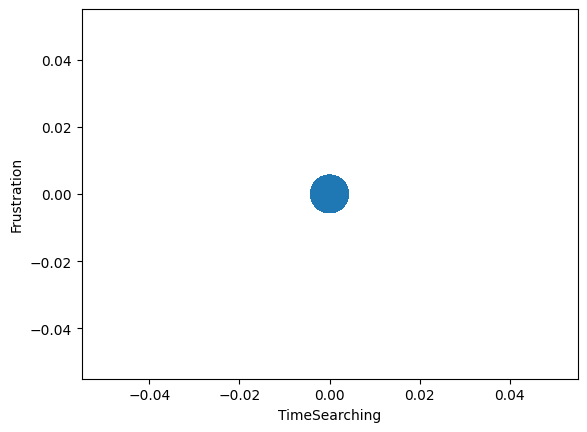

In [24]:
#Create a bubble plot of TimeSearching and Frustration using the Age column as the bubble size
QUERY = """
SELECT TimeSearching, Frustration, Age
FROM main
"""
# Assign the result of the SQL query to a new DataFrame
plot_data = pd.read_sql_query(QUERY, conn)

# Define a mapping for Age categories to numerical values for bubble size
age_mapping = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70,
    'Prefer not to say': 0 # Assign 0 for 'Prefer not to say' or missing ages
}

# Apply the mapping to create a new numerical 'Age_numeric' column
plot_data['Age_numeric'] = plot_data['Age'].map(age_mapping)
# Fill any potential None/NaN values in 'Age_numeric' with a default (e.g., 0)
plot_data['Age_numeric'].fillna(0, inplace=True)

# Convert 'TimeSearching' and 'Frustration' to numeric, coercing errors to NaN, then fill NaN with 0
plot_data['TimeSearching'] = pd.to_numeric(plot_data['TimeSearching'], errors='coerce').fillna(0)
plot_data['Frustration'] = pd.to_numeric(plot_data['Frustration'], errors='coerce').fillna(0)

# Use the new numerical 'Age_numeric' column for the 's' (size) parameter.
# Scale the size for better visualization (e.g., multiply by 10).
plot_data.plot(kind='scatter', x='TimeSearching', y='Frustration', s=plot_data['Age_numeric'] * 10)

,DatabaseWantToWorkWith,Count
0,PostgreSQL,3738
1,PostgreSQL;SQLite,1533
2,SQLite,1476
3,Microsoft SQL Server,1431
4,MySQL,1139


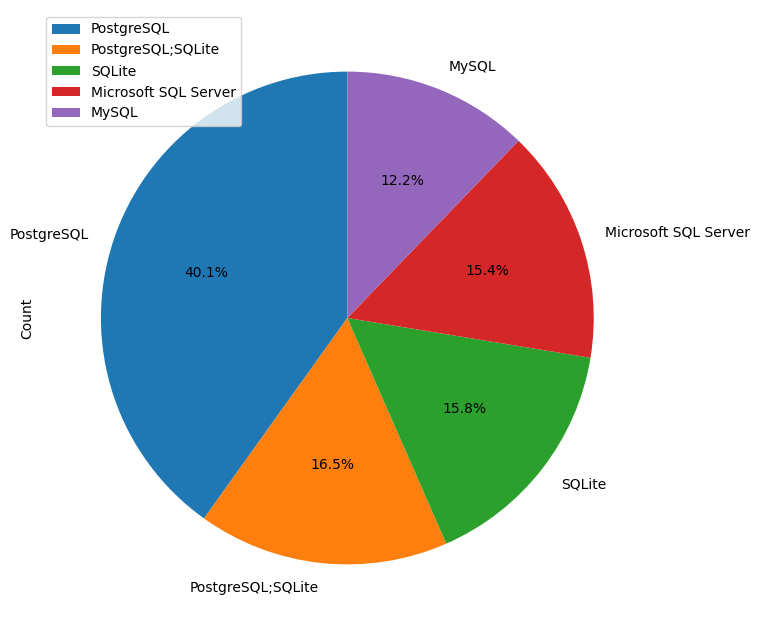

In [28]:
# Create a pie chart of the top 5 databases that respondents wish to learn next year.
QUERY = """
SELECT DatabaseWantToWorkWith, COUNT(*) AS Count
FROM main
WHERE DatabaseWantToWorkWith IS NOT NULL
GROUP BY DatabaseWantToWorkWith
ORDER BY Count DESC
LIMIT 5
"""

# Execute the query and store results in a DataFrame for plotting and labels
plot_data = pd.read_sql_query(QUERY, conn)

# Create the pie chart
plot_data.plot(kind='pie', y='Count', labels=plot_data['DatabaseWantToWorkWith'], autopct='%1.1f%%', startangle=90, figsize=(8, 8))

# Display the data used for the pie chart
plot_data

               Age  TimeSearching  TimeAnswering
0  25-34 years old            NaN            NaN
1  35-44 years old            NaN            NaN


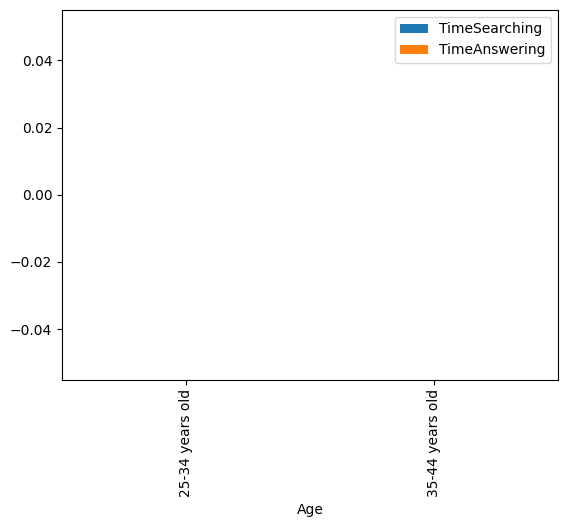

In [32]:
#Create a stacked bar chart of median TimeSearching and TimeAnswering for the age group 30 to 35
QUERY = """
SELECT Age, TimeSearching, TimeAnswering
FROM main
"""

plot_data = pd.read_sql_query(QUERY, conn)

# Convert TimeSearching and TimeAnswering to numeric, coercing errors to NaN
plot_data['TimeSearching'] = pd.to_numeric(plot_data['TimeSearching'], errors='coerce')
plot_data['TimeAnswering'] = pd.to_numeric(plot_data['TimeAnswering'], errors='coerce')

# Define the age groups that cover 30 to 35 years old
relevant_age_groups = ['25-34 years old', '35-44 years old']

# Filter the data for the relevant age groups
filtered_data = plot_data[plot_data['Age'].isin(relevant_age_groups)]

# Calculate the median TimeSearching and TimeAnswering for each age group
median_data = filtered_data.groupby('Age')[['TimeSearching', 'TimeAnswering']].median().reset_index()

# Plot the stacked bar chart
median_data.plot(kind='bar', x='Age', y=['TimeSearching', 'TimeAnswering'], stacked=True)

# Display the median data
print(median_data)

               Age  CompTotal  Age_Order
0  45-54 years old   130000.0          1
1  55-64 years old   135000.0          2


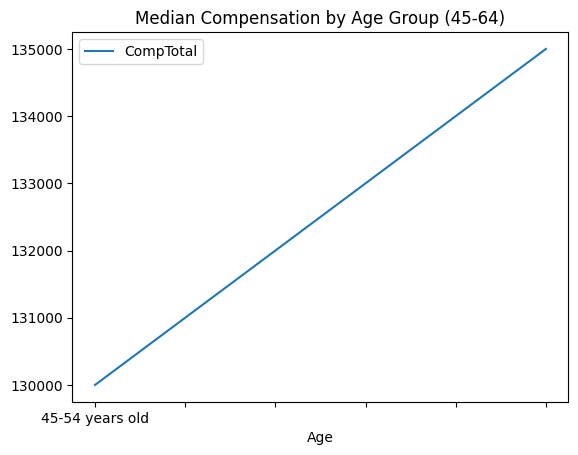

In [36]:
#Plot a line chart for the median CompTotal for all ages from 45 to 60
QUERY = """
SELECT Age, CompTotal
FROM main
"""

plot_data = pd.read_sql_query(QUERY, conn)

# Convert CompTotal to numeric, coercing errors to NaN
plot_data['CompTotal'] = pd.to_numeric(plot_data['CompTotal'], errors='coerce')

# Define the age groups that cover 45 to 60
relevant_age_groups = ['45-54 years old', '55-64 years old'] # Adjusted to strictly cover up to 60 based on categories

# Filter the data for the relevant age groups
filtered_data = plot_data[plot_data['Age'].isin(relevant_age_groups)]

# Calculate the median CompTotal for each age group
median_comp_data = filtered_data.groupby('Age')['CompTotal'].median().reset_index()

# Define a custom order for age groups for correct plotting order
age_order = {'45-54 years old': 1, '55-64 years old': 2}
median_comp_data['Age_Order'] = median_comp_data['Age'].map(age_order)
median_comp_data = median_comp_data.sort_values('Age_Order')

# Plot the line chart
median_comp_data.plot(kind='line', x='Age', y='CompTotal', title='Median Compensation by Age Group (45-64)')

# Display the median data
print(median_comp_data)

<Axes: >

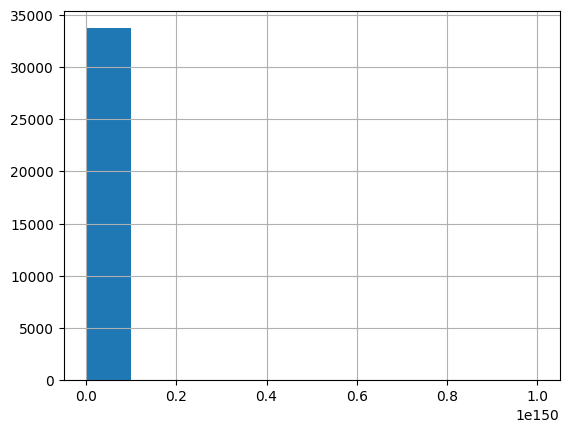

In [39]:
#Plot a histogram of CompTotal to visualize the distribution of respondents' total compensation
QUERY = """
SELECT CompTotal
FROM main
"""

plot_data = pd.read_sql_query(QUERY, conn)
pd.to_numeric(plot_data['CompTotal'], errors='coerce').hist()

<Axes: >

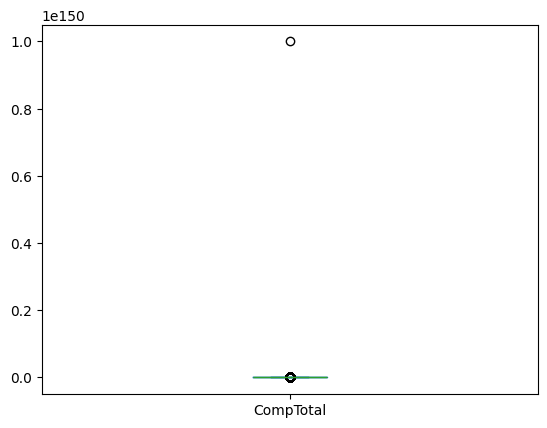

In [40]:
#Use a box plot to analyze the distribution and outliers in total compensation
QUERY = """
SELECT CompTotal
FROM main
"""

plot_data = pd.read_sql_query(QUERY, conn)
pd.to_numeric(plot_data['CompTotal'], errors='coerce').plot(kind='box')


                  Age  Age_numeric
0  Under 18 years old         15.0
1     35-44 years old         39.5
2     45-54 years old         49.5
3     18-24 years old         21.0
4     18-24 years old         21.0


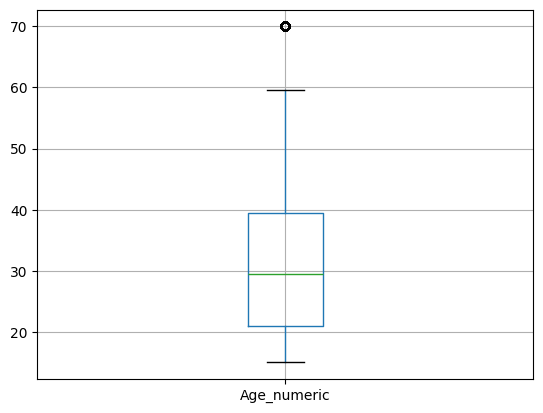

In [43]:
#Convert the Age column into numerical values and visualize the distribution with a boxplot
QUERY = """
SELECT Age
FROM main
"""

plot_data = pd.read_sql_query(QUERY, conn)

# Define a mapping for Age categories to numerical values
age_mapping = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70,
    'Prefer not to say': None # Assign None for 'Prefer not to say' to be dropped or handled later
}

# Apply the mapping to create a new numerical 'Age_numeric' column
plot_data['Age_numeric'] = plot_data['Age'].map(age_mapping)

# Drop rows where 'Age_numeric' is NaN (e.g., 'Prefer not to say') as they can't be plotted numerically
plot_data.dropna(subset=['Age_numeric'], inplace=True)

# Create the boxplot
plot_data.boxplot(column='Age_numeric')

# Display the numerical age data (first few rows)
print(plot_data.head())

<Axes: >

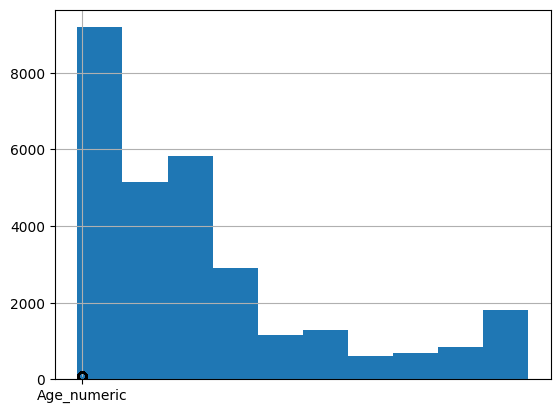

In [45]:
#Visualize the relationship between respondents' age (Age) and job satisfaction (JobSatPoints_6).
QUERY = """
SELECT Age, JobSatPoints_6
FROM main
"""

plot_data = pd.read_sql_query(QUERY, conn)

# Define a mapping for Age categories to numerical values
age_mapping = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70,
    'Prefer not to say': None # Assign None for 'Prefer not to say' to be dropped or handled later
}

# Apply the mapping to create a new numerical 'Age_numeric' column
plot_data['Age_numeric'] = plot_data['Age'].map(age_mapping)

# Drop rows where 'Age_numeric' is NaN (e.g., 'Prefer not to say') as they can't be plotted numerically
plot_data.dropna(subset=['Age_numeric'], inplace=True)

pd.to_numeric(plot_data['JobSatPoints_6'], errors='coerce').hist()
plot_data.boxplot(column='Age_numeric')

     ConvertedCompYearly  JobSatPoints_6
72                7322.0            65.0
379              91295.0             0.0
389             110000.0            20.0
392             161044.0            30.0
398             195000.0            30.0


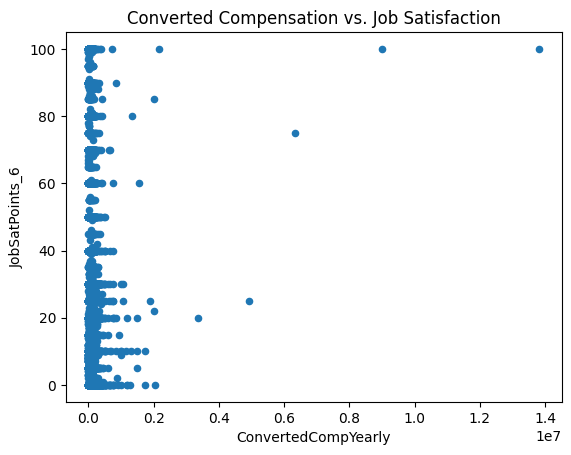

In [48]:
#Explore the relationship between (ConvertedCompYearly)and (JobSatPoints_6) using a scatter plot
QUERY = """
SELECT ConvertedCompYearly, JobSatPoints_6
FROM main
"""

plot_data = pd.read_sql_query(QUERY, conn)

# Convert columns to numeric, coercing errors to NaN
plot_data['ConvertedCompYearly'] = pd.to_numeric(plot_data['ConvertedCompYearly'], errors='coerce')
plot_data['JobSatPoints_6'] = pd.to_numeric(plot_data['JobSatPoints_6'], errors='coerce')

# Drop rows with NaN values in either column to ensure clean plotting
plot_data.dropna(subset=['ConvertedCompYearly', 'JobSatPoints_6'], inplace=True)

# Create the scatter plot
plot_data.plot(kind='scatter', x='ConvertedCompYearly', y='JobSatPoints_6', title='Converted Compensation vs. Job Satisfaction')

# Display the first few rows of the data used for plotting
print(plot_data.head())

<Axes: title={'center': 'Converted Compensation vs. Job Satisfaction (Bubble size by Age)'}, xlabel='ConvertedCompYearly', ylabel='JobSatPoints_6'>

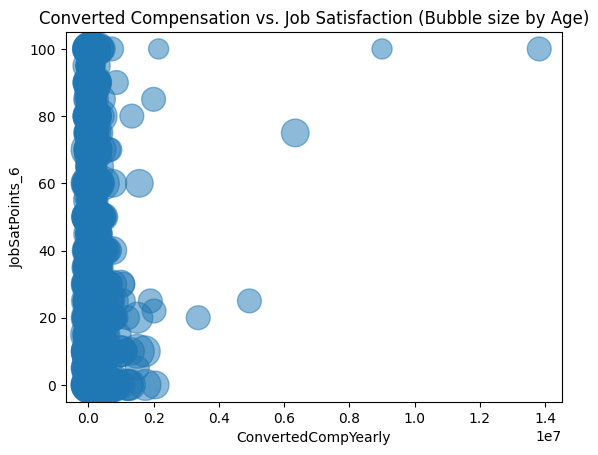

In [50]:
# Create a bubble plot to explore the relationship between yearly compensation
# (ConvertedCompYearly) and job satisfaction (JobSatPoints_6), with bubble size
# representing age
QUERY = """
SELECT ConvertedCompYearly, JobSatPoints_6, Age
FROM main
"""

plot_data = pd.read_sql_query(QUERY,conn)

# Convert numerical columns to numeric, coercing errors
plot_data['ConvertedCompYearly'] = pd.to_numeric(plot_data['ConvertedCompYearly'], errors='coerce')
plot_data['JobSatPoints_6'] = pd.to_numeric(plot_data['JobSatPoints_6'], errors='coerce')

# Define a mapping for Age categories to numerical values for bubble size
age_mapping = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70,
    'Prefer not to say': 0 # Assign 0 for 'Prefer not to say' or missing ages
}

# Apply the mapping to create a new numerical 'Age_numeric' column
plot_data['Age_numeric'] = plot_data['Age'].map(age_mapping)

# Drop rows with NaN values in any of the plotting columns to ensure clean plot
plot_data.dropna(subset=['ConvertedCompYearly', 'JobSatPoints_6', 'Age_numeric'], inplace=True)

# Create the bubble plot
# Scale the size for better visualization (e.g., multiply by a factor)
plot_data.plot(kind='scatter',
               x='ConvertedCompYearly',
               y='JobSatPoints_6',
               s=plot_data['Age_numeric'] * 10, # Multiply by 10 or another factor to make bubbles visible
               alpha=0.5, # Add transparency for overlapping bubbles
               title='Converted Compensation vs. Job Satisfaction (Bubble size by Age)')


<Axes: xlabel='Age'>

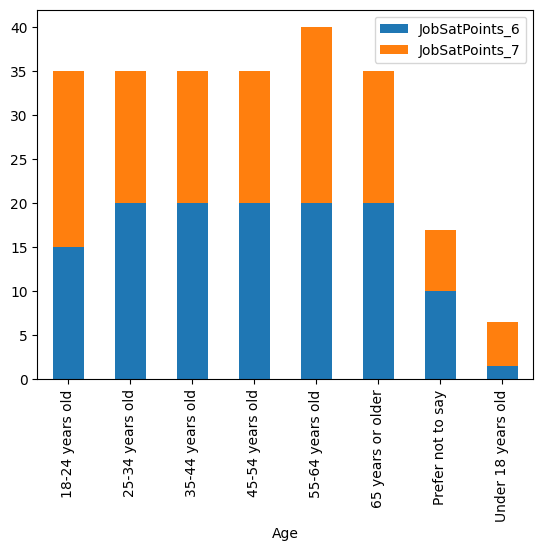

In [54]:
#create a Stacked Chart of Median JobSatPoints_6 and JobSatPoints_7 for Different Age Groups
QUERY = """
SELECT Age, JobSatPoints_6, JobSatPoints_7
FROM main
"""

plot_data = pd.read_sql_query(QUERY, conn)

plot_data['JobSatPoints_6'] = pd.to_numeric(plot_data['JobSatPoints_6'], errors='coerce')
plot_data['JobSatPoints_7'] = pd.to_numeric(plot_data['JobSatPoints_7'], errors='coerce')

plot_data.groupby('Age')[['JobSatPoints_6', 'JobSatPoints_7']].median().plot(kind='bar', stacked=True)

               Age  ConvertedCompYearly  Age_Order
0  25-34 years old              59825.0          1
1  35-44 years old              84796.0          2


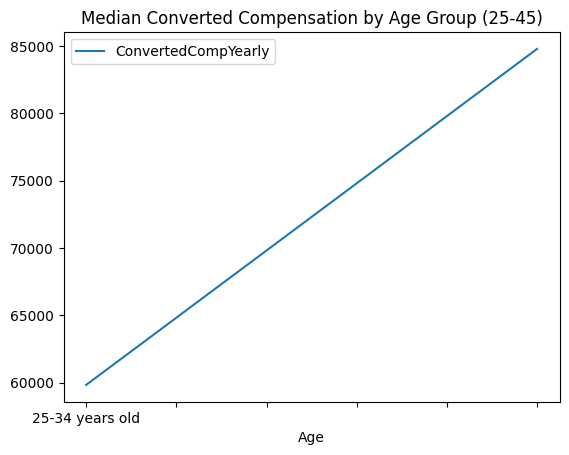

In [56]:
#create a Line Chart of Median 'ConvertedCompYearly' for Ages 25 to 45
QUERY = """
SELECT ConvertedCompYearly, Age
FROM main
"""

plot_data = pd.read_sql_query(QUERY, conn)
plot_data['ConvertedCompYearly'] = pd.to_numeric(plot_data['ConvertedCompYearly'], errors='coerce')

# Define the age groups that cover 25 to 45 years old
# Assuming Age column has categories like '25-34 years old', '35-44 years old'
relevant_age_groups = ['25-34 years old', '35-44 years old']

# Filter the data for the relevant age groups
filtered_data = plot_data[plot_data['Age'].isin(relevant_age_groups)]

# Calculate the median ConvertedCompYearly for each age group
median_comp_data = filtered_data.groupby('Age')['ConvertedCompYearly'].median().reset_index()

# Define a custom order for age groups for correct plotting order
age_order = {'25-34 years old': 1, '35-44 years old': 2}
median_comp_data['Age_Order'] = median_comp_data['Age'].map(age_order)
median_comp_data = median_comp_data.sort_values('Age_Order')

# Plot the line chart
median_comp_data.plot(kind='line', x='Age', y='ConvertedCompYearly', title='Median Converted Compensation by Age Group (25-45)')

# Display the median data
print(median_comp_data)

In [57]:
conn.close()